# OffSide 2026 — Football Analytics Datathon
**Objective:** Predict `scored_flag` (probability a player scores ≥1 goal in a match)  
**Metric:** Average Precision (AP)  
**Strategy:** LightGBM with stratified k-fold, native null handling, careful leakage removal

## 1. Setup & Imports

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay
from sklearn.preprocessing import LabelEncoder

SEED = 42
N_FOLDS = 5
N_TRIALS = 50  # Optuna tuning trials — reduce to 30 if short on time

np.random.seed(SEED)
print('Setup complete')

Setup complete


## 2. Load Data

In [19]:
train = pd.read_csv('/kaggle/input/datasets/abhinavpandey2005/official/train.csv')
test  = pd.read_csv('/kaggle/input/datasets/abhinavpandey2005/official/test.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'\nTarget distribution:')
print(train['scored_flag'].value_counts())
print(f'\nScoring rate: {train["scored_flag"].mean()*100:.2f}%')

# Convert boolean object columns to numeric with explicit missing value
mapping = {False: 0, True: 1}

for df in [train, test]:
    for col in ['has_understat', 'analytics_coverage_flag']:
        if col in df.columns:
            df[col] = (
                df[col]
                .map(mapping)
                .fillna(-1)      # missing becomes -1
                .astype(int)
            )

/tmp/ipykernel_58/2844594288.py:1: DtypeWarning: Columns (39,58) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/kaggle/input/datasets/abhinavpandey2005/official/train.csv')


Train: (1319813, 64)  |  Test: (565635, 63)

Target distribution:
scored_flag
False    1207131
True      112682
Name: count, dtype: int64

Scoring rate: 8.54%


## 3. Exploratory Data Analysis

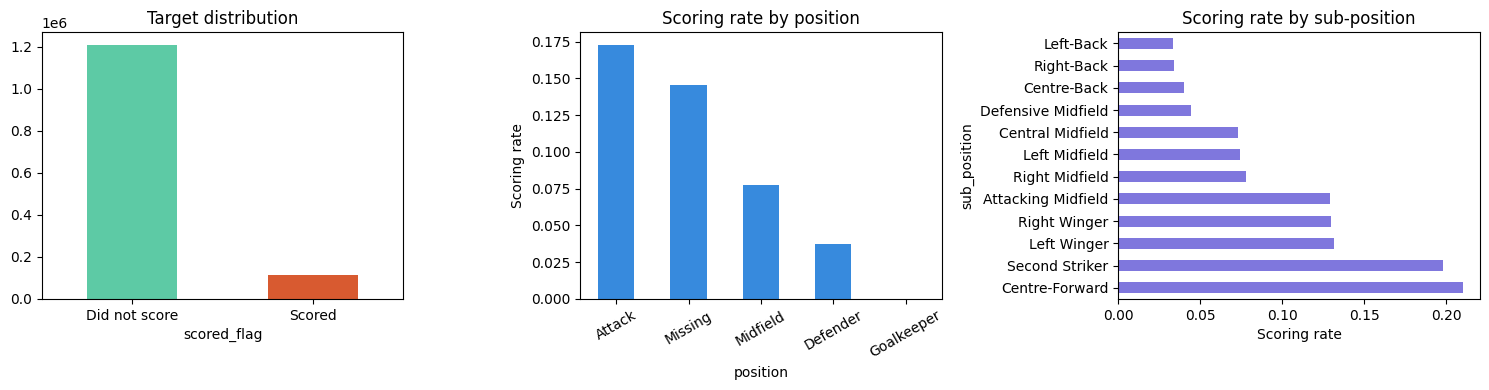

In [20]:
# --- Class balance ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target distribution
train['scored_flag'].value_counts().plot(kind='bar', ax=axes[0], color=['#5DCAA5','#D85A30'])
axes[0].set_title('Target distribution')
axes[0].set_xticklabels(['Did not score', 'Scored'], rotation=0)

# Scoring rate by position
pos_rate = train.groupby('position')['scored_flag'].mean().sort_values(ascending=False)
pos_rate.plot(kind='bar', ax=axes[1], color='#378ADD')
axes[1].set_title('Scoring rate by position')
axes[1].set_ylabel('Scoring rate')
axes[1].tick_params(axis='x', rotation=30)

# Scoring rate by sub_position
sub_rate = train.groupby('sub_position')['scored_flag'].mean().sort_values(ascending=False).head(12)
sub_rate.plot(kind='barh', ax=axes[2], color='#7F77DD')
axes[2].set_title('Scoring rate by sub-position')
axes[2].set_xlabel('Scoring rate')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# --- xG coverage analysis ---
print('=== xG Feature Coverage ===')
print(f"has_understat=True:  {train['has_understat'].mean()*100:.1f}% of rows")
print(f"  Scoring rate (with xG):    {train[train['has_understat']==True]['scored_flag'].mean()*100:.2f}%")
print(f"  Scoring rate (without xG): {train[train['has_understat']==False]['scored_flag'].mean()*100:.2f}%")

print('\n=== Null rates for key features ===')
nulls = train.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False).to_string())

=== xG Feature Coverage ===
has_understat=True:  52.2% of rows
  Scoring rate (with xG):    9.31%
  Scoring rate (without xG): 7.70%

=== Null rates for key features ===
goal_per_cap                   698431
xG_to_xA_ratio                 659447
avg_key_passes                 631205
avg_xG                         631205
avg_xA                         631205
avg_xGBuildup                  631205
avg_xGChain                    631205
avg_shots                      631205
avg_npxG                       631205
attendance                     141222
country_name                   103034
foot                            14339
market_value_before_match       11702
value_pct_of_peak               11702
market_value_tier               11702
log_market_value                11702
height_in_cm                    11145
country_of_citizenship          10824
referee                          1814
market_value_ratio               1666
highest_market_value_in_eur      1666
stadium                         

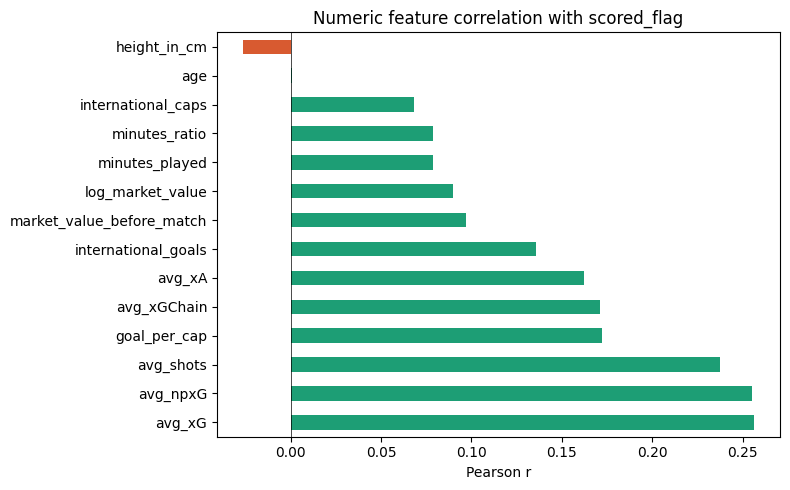

avg_xG                       0.257
avg_npxG                     0.255
avg_shots                    0.237
goal_per_cap                 0.172
avg_xGChain                  0.171
avg_xA                       0.162
international_goals          0.136
market_value_before_match    0.097
log_market_value             0.090
minutes_played               0.079
minutes_ratio                0.079
international_caps           0.068
age                          0.000
height_in_cm                -0.027


In [22]:
# --- Key feature correlations ---
num_cols = ['avg_xG', 'avg_npxG', 'avg_shots', 'avg_xGChain', 'avg_xA',
            'goal_per_cap', 'minutes_played', 'minutes_ratio',
            'log_market_value', 'market_value_before_match',
            'international_goals', 'international_caps', 'age', 'height_in_cm']

corrs = train[num_cols + ['scored_flag']].corr()['scored_flag'].drop('scored_flag').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1D9E75' if v > 0 else '#D85A30' for v in corrs.values]
corrs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Numeric feature correlation with scored_flag')
ax.set_xlabel('Pearson r')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

print(corrs.round(3).to_string())

In [23]:
# --- Boolean feature scoring rates ---
bool_cols = ['finisher_flag', 'is_attacker', 'is_midfielder', 'is_defender',
             'is_goalkeeper', 'starter_flag', 'full_match_flag', 'substitute_flag',
             'prime_age_flag', 'creative_player_flag', 'has_national_team_experience',
             'has_understat', 'veteran_flag']

rows = []
for c in bool_cols:
    if c in train.columns:
        r_true  = train[train[c]==True]['scored_flag'].mean()
        r_false = train[train[c]==False]['scored_flag'].mean()
        rows.append({'feature': c, 'rate_true': r_true, 'rate_false': r_false, 'lift': r_true - r_false})

bool_df = pd.DataFrame(rows).sort_values('lift', ascending=False)
print(bool_df.round(3).to_string(index=False))

                     feature  rate_true  rate_false   lift
                 is_attacker      0.173       0.051  0.122
               finisher_flag      0.146       0.064  0.082
        creative_player_flag      0.127       0.071  0.056
                starter_flag      0.100       0.049  0.050
has_national_team_experience      0.096       0.076  0.020
               has_understat      0.093       0.077  0.016
             full_match_flag      0.089       0.081  0.008
                veteran_flag      0.086       0.084  0.002
              prime_age_flag      0.086       0.085  0.001
               is_midfielder      0.077       0.089 -0.011
             substitute_flag      0.049       0.100 -0.050
                 is_defender      0.037       0.110 -0.073
               is_goalkeeper      0.000       0.092 -0.092


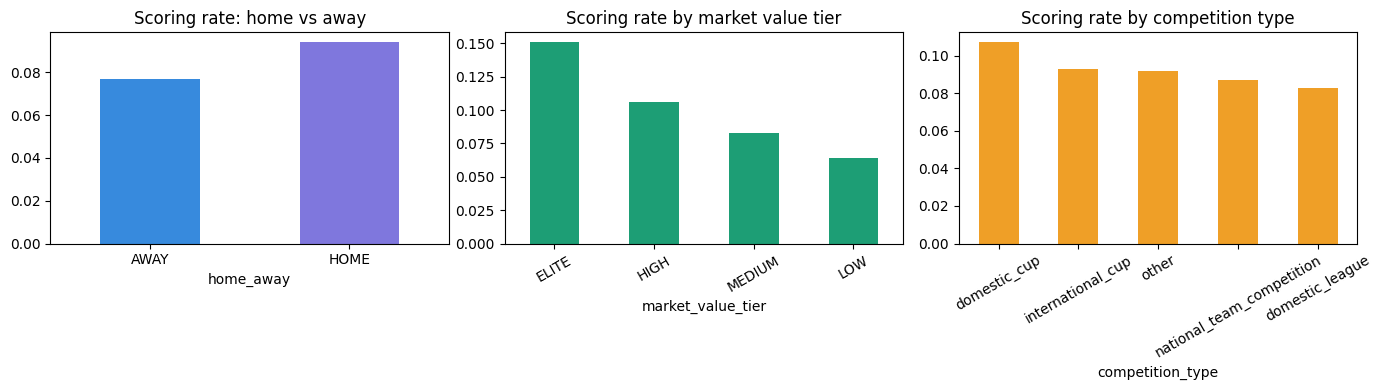

In [24]:
# --- Context features ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

home_rate = train.groupby('home_away')['scored_flag'].mean()
home_rate.plot(kind='bar', ax=axes[0], color=['#378ADD','#7F77DD'])
axes[0].set_title('Scoring rate: home vs away')
axes[0].tick_params(axis='x', rotation=0)

tier_rate = train.groupby('market_value_tier')['scored_flag'].mean().sort_values(ascending=False)
tier_rate.plot(kind='bar', ax=axes[1], color='#1D9E75')
axes[1].set_title('Scoring rate by market value tier')
axes[1].tick_params(axis='x', rotation=30)

comp_rate = train.groupby('competition_type')['scored_flag'].mean().sort_values(ascending=False)
comp_rate.plot(kind='bar', ax=axes[2], color='#EF9F27')
axes[2].set_title('Scoring rate by competition type')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_context_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

In [25]:
def engineer_features(df):
    df = df.copy()

    # --- Drop leakage columns ---
    # home/away_club_goals and goal_diff_abs are post-match final scores
    # They correlate with scored_flag because high-scoring games produce more scorers
    leakage_cols = ['home_club_goals', 'away_club_goals', 'goal_diff_abs']
    df.drop(columns=[c for c in leakage_cols if c in df.columns], inplace=True)

    # --- Drop identifier / low-value cols ---
    drop_cols = ['appearance_id', 'date', 'home_club_id', 'away_club_id',
                 'home_club_name', 'away_club_name', 'stadium', 'referee',
                 'name_x', 'name_y', 'player_name', 'country_of_citizenship']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # --- xG interaction features (only meaningful when xG data exists) ---
    df['xG_per_shot'] = df['avg_xG'] / (df['avg_shots'] + 1e-6)
    df['xG_x_minutes'] = df['avg_xG'] * df['minutes_ratio']
    df['npxG_x_minutes'] = df['avg_npxG'] * df['minutes_ratio']
    df['shot_volume_x_minutes'] = df['avg_shots'] * df['minutes_ratio']
    df['xG_x_finisher'] = df['avg_xG'] * df['finisher_flag'].astype(float)
    df['xG_x_attacker'] = df['avg_xG'] * df['is_attacker'].astype(float)

    # --- Market value features ---
    df['mv_x_attacker'] = df['log_market_value'].fillna(0) * df['is_attacker'].astype(float)
    df['mv_x_minutes']  = df['log_market_value'].fillna(0) * df['minutes_ratio']

    # --- International scoring ability ---
    df['intl_goal_rate'] = df['international_goals'] / (df['international_caps'] + 1e-6)
    df['intl_goal_rate'] = df['intl_goal_rate'].fillna(0)

    # --- Position-aware market value ---
    # Attackers with high value are most likely to score
    df['elite_attacker'] = (df['market_value_tier'] == 'ELITE') & (df['is_attacker'])
    df['elite_attacker'] = df['elite_attacker'].astype(float)

    # --- Goalkeeper hard signal ---
    # Goalkeepers never score — make this explicit
    df['is_goalkeeper_int'] = df['is_goalkeeper'].astype(int)

    # --- Minutes buckets ---
    df['played_full_90'] = (df['minutes_played'] >= 85).astype(int)
    df['played_over_60'] = (df['minutes_played'] >= 60).astype(int)
    df['is_impact_sub']  = ((df['substitute_flag']) & (df['minutes_played'] >= 30)).astype(int)

    # --- Season as integer (already is, but ensure) ---
    df['season'] = df['season'].astype(int)

    # --- Encode categoricals ---
    cat_cols = ['home_away', 'competition_type', 'confederation',
                'market_value_tier', 'position', 'sub_position',
                'foot', 'age_bucket', 'country_name']
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype('category')

    return df


train_fe = engineer_features(train)
test_fe  = engineer_features(test)

print(f'Train after FE: {train_fe.shape}')
print(f'Test after FE:  {test_fe.shape}')
print('\nNew features added:')
new_cols = set(train_fe.columns) - set(train.columns)
print(sorted(new_cols))

Train after FE: (1319813, 64)
Test after FE:  (565635, 63)

New features added:
['elite_attacker', 'intl_goal_rate', 'is_goalkeeper_int', 'is_impact_sub', 'mv_x_attacker', 'mv_x_minutes', 'npxG_x_minutes', 'played_full_90', 'played_over_60', 'shot_volume_x_minutes', 'xG_per_shot', 'xG_x_attacker', 'xG_x_finisher', 'xG_x_minutes']


## 5. Prepare Model Inputs

In [26]:
TARGET = 'scored_flag'

# Columns to drop from features
drop_from_X = [TARGET, 'scored_flag']

feature_cols = [c for c in train_fe.columns if c not in drop_from_X]

# Align train and test columns
feature_cols = [c for c in feature_cols if c in test_fe.columns]

X = train_fe[feature_cols]
y = train_fe[TARGET].astype(int)
X_test = test_fe[feature_cols]

# Store appearance_id for submission
test_ids = test['appearance_id']

print(f'Features: {len(feature_cols)}')
print(f'X shape: {X.shape} | X_test shape: {X_test.shape}')
print(f'\nPositive rate: {y.mean()*100:.2f}%')
print(f'\nCategorical features:')
print([c for c in feature_cols if X[c].dtype.name == 'category'])

Features: 63
X shape: (1319813, 63) | X_test shape: (565635, 63)

Positive rate: 8.54%

Categorical features:
['home_away', 'country_name', 'competition_type', 'confederation', 'foot', 'position', 'sub_position', 'market_value_tier', 'age_bucket']


## 6. Baseline LightGBM (Stratified K-Fold)

In [27]:
print(train['has_understat'].unique())
print(train['analytics_coverage_flag'].unique())

print(train[['has_understat','analytics_coverage_flag']].dtypes)

[ 1  0 -1]
[ 1  0 -1]
has_understat              int64
analytics_coverage_flag    int64
dtype: object


In [28]:
def run_lgbm(X, y, X_test, params, n_folds=5, seed=42):
    """Stratified k-fold LightGBM. Returns OOF preds and test preds."""
    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    ap_scores  = []

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    cat_features = [c for c in X.columns if X[c].dtype.name == 'category']

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params, random_state=seed, verbose=-1)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = val_prob

        test_preds += model.predict_proba(X_test)[:, 1] / n_folds

        ap = average_precision_score(y_val, val_prob)
        ap_scores.append(ap)
        print(f'  Fold {fold+1}  |  AP: {ap:.4f}  |  best_iter: {model.best_iteration_}')

    oof_ap = average_precision_score(y, oof_preds)
    print(f'\nOOF AP: {oof_ap:.4f}  |  Mean fold AP: {np.mean(ap_scores):.4f} ± {np.std(ap_scores):.4f}')
    return oof_preds, test_preds, ap_scores, oof_ap


# Baseline params
baseline_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'n_estimators': 2000,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scale_pos_weight': (y == 0).sum() / (y == 1).sum(),  # handle imbalance
    'n_jobs': -1,
}

print('=== BASELINE LIGHTGBM ===')
print(f'scale_pos_weight: {baseline_params["scale_pos_weight"]:.2f}')
print()
oof_base, test_base, ap_base, oof_ap_base = run_lgbm(X, y, X_test, baseline_params, N_FOLDS, SEED)

=== BASELINE LIGHTGBM ===
scale_pos_weight: 10.71

  Fold 1  |  AP: 0.2831  |  best_iter: 694
  Fold 2  |  AP: 0.2854  |  best_iter: 497
  Fold 3  |  AP: 0.2850  |  best_iter: 687
  Fold 4  |  AP: 0.2875  |  best_iter: 461
  Fold 5  |  AP: 0.2814  |  best_iter: 676

OOF AP: 0.2843  |  Mean fold AP: 0.2845 ± 0.0021


## 7. Hyperparameter Tuning with Optuna

In [3]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import lightgbm as lgb
import optuna
import numpy as np

def objective(trial):

    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'random_state': SEED,
        'n_jobs': -1,
        'verbosity': -1,

        # Fixed
        'n_estimators': 5000,
        'scale_pos_weight': (y == 0).sum() / (y == 1).sum(),

        # Search space
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.05, log=True
        ),

        'num_leaves': trial.suggest_int(
            'num_leaves', 31, 127
        ),

        'min_child_samples': trial.suggest_int(
            'min_child_samples', 20, 100
        ),

        'subsample': trial.suggest_float(
            'subsample', 0.6, 1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree', 0.6, 1.0
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha', 1e-4, 1.0, log=True
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda', 1e-4, 1.0, log=True
        )
    }

    skf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=SEED
    )

    scores = []

    for tr_idx, val_idx in skf.split(X, y):

        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )

        preds = model.predict_proba(X_val)[:, 1]

        score = average_precision_score(y_val, preds)
        scores.append(score)

    return np.mean(scores)

## 8. Final Model with Best Params

In [ ]:
best_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'n_estimators': 3000,
    'n_jobs': -1,
    'scale_pos_weight': (y == 0).sum() / (y == 1).sum(),
    **study.best_params
}

print('=== TUNED LIGHTGBM (5-fold) ===')
oof_tuned, test_tuned, ap_tuned, oof_ap_tuned = run_lgbm(X, y, X_test, best_params, N_FOLDS, SEED)

print(f'\nBaseline OOF AP: {oof_ap_base:.4f}')
print(f'Tuned OOF AP:    {oof_ap_tuned:.4f}')
print(f'Improvement:     {(oof_ap_tuned - oof_ap_base)*100:+.2f} pp')

## 9. Feature Importance

In [ ]:
# Train on full data to get stable feature importances
final_model = lgb.LGBMClassifier(**best_params, random_state=SEED, verbose=-1)
final_model.fit(X, y)

fi = pd.DataFrame({
    'feature': feature_cols,
    'importance_gain': final_model.booster_.feature_importance(importance_type='gain'),
    'importance_split': final_model.booster_.feature_importance(importance_type='split'),
}).sort_values('importance_gain', ascending=False)

print('Top 20 features by gain:')
print(fi.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 10))
top_fi = fi.head(25)
ax.barh(top_fi['feature'][::-1], top_fi['importance_gain'][::-1], color='#378ADD')
ax.set_title('Top 25 features — LightGBM gain importance')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Validation Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision-Recall curve
display = PrecisionRecallDisplay.from_predictions(
    y, oof_tuned, ax=axes[0], name=f'LightGBM (AP={oof_ap_tuned:.4f})'
)
axes[0].set_title('OOF Precision-Recall Curve')

# Predicted probability distribution by class
axes[1].hist(oof_tuned[y==0], bins=50, alpha=0.6, label='Did not score', color='#5DCAA5', density=True)
axes[1].hist(oof_tuned[y==1], bins=50, alpha=0.6, label='Scored', color='#D85A30', density=True)
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Density')
axes[1].set_title('OOF predicted probability distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('validation_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

# Score by position (sanity check)
val_df = train[['position', 'is_goalkeeper']].copy()
val_df['oof_prob'] = oof_tuned
val_df['scored_flag'] = y.values
print('\nMean predicted probability by position (sanity check):')
print(val_df.groupby('position')[['oof_prob', 'scored_flag']].mean().round(3))

## 11. Goalkeeper Probability Override

In [ ]:
# Goalkeepers score at 0% in training — cap their predicted probability
GK_CAP = 0.005

test_final = test_tuned.copy()
gk_mask = test['is_goalkeeper'].values.astype(bool)
n_gk = gk_mask.sum()
test_final[gk_mask] = np.minimum(test_final[gk_mask], GK_CAP)

print(f'Goalkeeper rows in test: {n_gk} ({n_gk/len(test)*100:.1f}%)')
print(f'GK prob before cap — mean: {test_tuned[gk_mask].mean():.4f}, max: {test_tuned[gk_mask].max():.4f}')
print(f'GK prob after cap  — mean: {test_final[gk_mask].mean():.4f}, max: {test_final[gk_mask].max():.4f}')

## 12. Generate Submission

In [30]:
submission = pd.DataFrame({
    'appearance_id': test_ids,
    'scored_flag': test_final
})

# Sanity checks
assert submission['appearance_id'].nunique() == len(submission), 'Duplicate appearance_ids!'
assert submission['scored_flag'].between(0, 1).all(), 'Probabilities out of [0,1]!'
assert submission.isnull().sum().sum() == 0, 'Nulls in submission!'

submission.to_csv('solution.csv', index=False)

print('=== SUBMISSION SUMMARY ===')
print(f'Rows: {len(submission)}')
print(f'Mean predicted probability: {submission["scored_flag"].mean():.4f}')
print(f'Median: {submission["scored_flag"].median():.4f}')
print(f'Min: {submission["scored_flag"].min():.6f} | Max: {submission["scored_flag"].max():.4f}')
print(f'\nTop 5 rows:')
print(submission.head())
print('\nsolution.csv saved!')

NameError: name 'test_final' is not defined

## 13. Optional: Two-Model Approach (xG vs Non-xG)

Run this if you have time and want to push AP higher. Trains separate models for players with/without Understat xG data.

In [ ]:
# Split by understat coverage
xg_mask_train  = train['has_understat'].values.astype(bool)
noxg_mask_train = ~xg_mask_train
xg_mask_test   = test['has_understat'].values.astype(bool)
noxg_mask_test  = ~xg_mask_test

print(f'Train — with xG: {xg_mask_train.sum()} | without xG: {noxg_mask_train.sum()}')
print(f'Test  — with xG: {xg_mask_test.sum()} | without xG: {noxg_mask_test.sum()}')

# xG-rich model (all features)
print('\n=== MODEL A: players WITH xG data ===')
X_xg = X[xg_mask_train]
y_xg = y[xg_mask_train]
X_test_xg = X_test[xg_mask_test]

params_a = {**best_params, 'scale_pos_weight': (y_xg==0).sum()/(y_xg==1).sum()}
oof_a, test_a, _, oof_ap_a = run_lgbm(X_xg, y_xg, X_test_xg, params_a, N_FOLDS, SEED)

# Non-xG model (xG features mostly null — drop them)
print('\n=== MODEL B: players WITHOUT xG data ===')
xg_feature_cols = ['avg_xG', 'avg_npxG', 'avg_shots', 'avg_xA', 'avg_key_passes',
                   'avg_xGChain', 'avg_xGBuildup', 'xG_to_xA_ratio',
                   'xG_per_shot', 'xG_x_minutes', 'npxG_x_minutes',
                   'shot_volume_x_minutes', 'xG_x_finisher', 'xG_x_attacker']
non_xg_features = [c for c in feature_cols if c not in xg_feature_cols]

X_noxg = X.loc[noxg_mask_train, non_xg_features]
y_noxg = y[noxg_mask_train]
X_test_noxg = X_test.loc[noxg_mask_test, non_xg_features]

params_b = {**best_params, 'scale_pos_weight': (y_noxg==0).sum()/(y_noxg==1).sum()}
oof_b, test_b, _, oof_ap_b = run_lgbm(X_noxg, y_noxg, X_test_noxg, params_b, N_FOLDS, SEED)

# Combine predictions
test_two_model = np.zeros(len(test))
test_two_model[xg_mask_test]   = test_a
test_two_model[noxg_mask_test] = test_b

oof_two_model = np.zeros(len(train))
oof_two_model[xg_mask_train]   = oof_a
oof_two_model[noxg_mask_train] = oof_b

oof_ap_two = average_precision_score(y, oof_two_model)
print(f'\nTwo-model OOF AP: {oof_ap_two:.4f}')
print(f'Single model OOF AP: {oof_ap_tuned:.4f}')
print(f'Difference: {(oof_ap_two - oof_ap_tuned)*100:+.2f} pp')

In [ ]:
# Pick the better model for final submission
if oof_ap_two > oof_ap_tuned:
    print('Two-model approach wins — using it for submission')
    final_probs = test_two_model.copy()
else:
    print('Single model wins — using it for submission')
    final_probs = test_tuned.copy()

# Apply goalkeeper cap regardless
final_probs[gk_mask] = np.minimum(final_probs[gk_mask], GK_CAP)

submission_final = pd.DataFrame({
    'appearance_id': test_ids,
    'scored_flag': final_probs
})
submission_final.to_csv('solution.csv', index=False)
print(f'Final solution.csv saved — mean prob: {final_probs.mean():.4f}')

---
## Summary

| Step | Detail |
|------|--------|
| Target | `scored_flag` — binary (9.5% positive rate) |
| Metric | Average Precision (AP) — ranking quality on imbalanced data |
| Leakage removed | `home_club_goals`, `away_club_goals`, `goal_diff_abs` |
| Key signals | `avg_xG`, `avg_npxG`, `avg_shots`, `is_attacker`, `finisher_flag`, `home_away`, `starter_flag` |
| Missing xG | 49% of rows — LightGBM handles natively; two-model approach tested |
| Validation | Stratified 5-fold CV | 
| Imbalance | `scale_pos_weight` in LightGBM |
| GK override | Capped at 0.005 (goalkeepers never score) |